In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

customers = pd.DataFrame({
    "customer_id": range(1, 21),
    "age": [25, 34, 45, 23, 56, 38, 29, 41, 52, 33,
            27, 48, 36, 44, 31, 39, 26, 50, 35, 42],
    "monthly_spend": [50, 120, 200, 30, 250, 90, 45, 180, 220, 100,
                       40, 210, 85, 190, 60, 95, 35, 240, 105, 175],
    "tenure_months": [3, 24, 48, 2, 60, 18, 4, 36, 55, 20,
                       3, 42, 15, 33, 6, 19, 2, 58, 22, 30],
    "churned": [1, 0, 0, 1, 0, 0, 1, 0, 0, 0,
                1, 0, 0, 0, 1, 0, 1, 0, 0, 0]
})

In [5]:
print(f"Data Shape: {customers.shape}")
print(customers.dtypes)
print(customers.describe())

Data Shape: (20, 5)
customer_id      int64
age              int64
monthly_spend    int64
tenure_months    int64
churned          int64
dtype: object
       customer_id        age  monthly_spend  tenure_months    churned
count     20.00000  20.000000      20.000000      20.000000  20.000000
mean      10.50000  37.700000     126.000000      25.000000   0.300000
std        5.91608   9.504016      74.632433      19.587859   0.470162
min        1.00000  23.000000      30.000000       2.000000   0.000000
25%        5.75000  30.500000      57.500000       5.500000   0.000000
50%       10.50000  37.000000     102.500000      21.000000   0.000000
75%       15.25000  44.250000     192.500000      37.500000   1.000000
max       20.00000  56.000000     250.000000      60.000000   1.000000


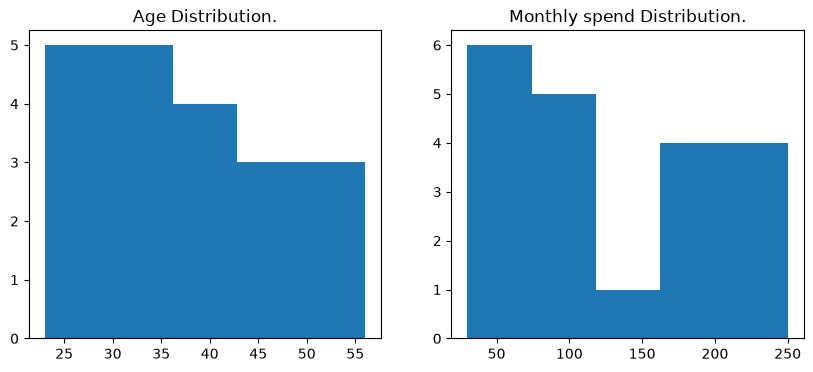

In [12]:
fig, axes = plt.subplots(1,2, figsize= (10,4))
axes[0].hist(customers['age'], bins=5)
axes[0].set_title("Age Distribution.")
axes[1].hist(customers['monthly_spend'], bins=5)
axes[1].set_title("Monthly spend Distribution.")
plt.show()

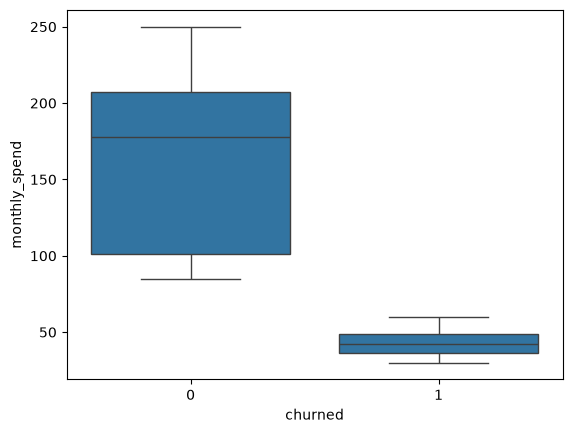

In [16]:
sns.boxplot(x="churned",y="monthly_spend", data=customers)
plt.show()

# Findings:
1. According to what i see on boxplot, it shows that more the person spends more he stays and less he   spends higher the chances of churn.

2. People spending lower than 80 has more chances to churn while the ones spending higher than 80-100 has more chances of staying.

In [31]:
def spend_tier_func(s):
        if s > 180:
            return "High"
        elif s > 80:
            return "Medium"
        else:
            return "Low"
customers['spend_tier'] = customers['monthly_spend'].apply(spend_tier_func)


In [24]:
def tenure_tier_func(t):
    if t > 36:
        return "Loyal"
    if t > 12:
        return "Established"
    else:
        return "New"

customers['tenure_tier'] = customers['tenure_months'].apply(tenure_tier_func)
customers

,customer_id,age,monthly_spend,tenure_months,churned,spend_tier,tenure_tier
0,1,25,50,3,1,Low,New
1,2,34,120,24,0,Medium,Established
2,3,45,200,48,0,High,Loyal
3,4,23,30,2,1,Low,New
4,5,56,250,60,0,High,Loyal
5,6,38,90,18,0,Medium,Established
6,7,29,45,4,1,Low,New
7,8,41,180,36,0,Medium,Established
8,9,52,220,55,0,High,Loyal
9,10,33,100,20,0,Medium,Established


In [35]:
print(customers.groupby('spend_tier')['churned'].mean())
print(customers.groupby('tenure_tier')['churned'].mean())

spend_tier
High      0.0
Low       1.0
Medium    0.0
Name: churned, dtype: float64
tenure_tier
Established    0.0
Loyal          0.0
New            1.0
Name: churned, dtype: float64


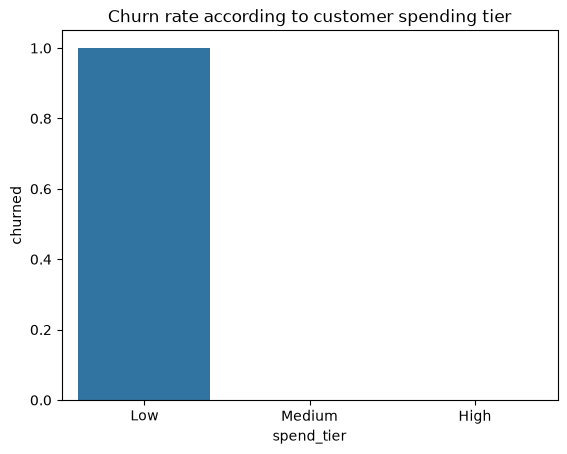

In [30]:
sns.barplot(x="spend_tier", y="churned", data=customers)
plt.title("Churn rate according to customer spending tier")
plt.show()

In [36]:
pd.crosstab(customers['spend_tier'], customers['tenure_tier'])

tenure_tier,Established,Loyal,New
spend_tier,,,
High,1,5,0
Low,0,0,6
Medium,8,0,0


The perfect churn separation by tier (100% vs 0%) is likely partly an artifact of the small sample size (20 customers). Additionally, spend_tier and tenure_tier are almost perfectly correlated with each other in this dataset (confirmed via crosstab); Low spend customers are always New, Medium spend customers are always Established, High spend customers are almost always Loyal. This suggests these aren't two independent risk signals but largely the same underlying pattern (customer tenure) expressed two ways. In a real dataset with more customers and more natural variation, I'd expect this clean separation to break down, and I'd treat spend_tier and tenure_tier as redundant rather than combining both in a predictive model.

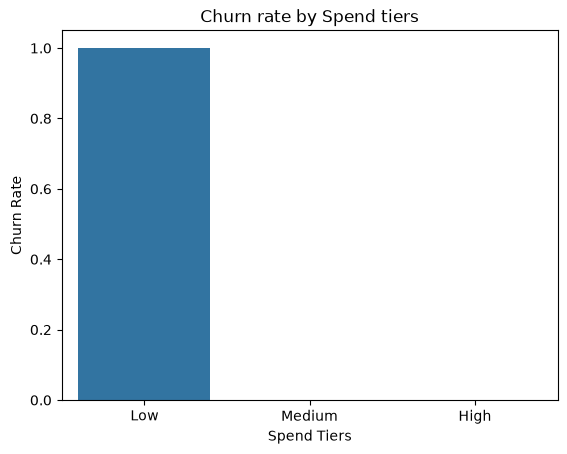

In [44]:
sns.barplot(x="spend_tier", y="churned", data=customers)
plt.title("Churn rate by Spend tiers")
plt.xlabel("Spend Tiers")
plt.ylabel("Churn Rate")
plt.savefig("churn_rate_spend_tier.png")
plt.show()